In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import seaborn as sns
import missingno as msno
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
data_FSVA_Nasional = pd.read_csv('D:/All Data I Have/FSVAnasional.csv')
data_FSVA_Nasional.head()

,Wilayah,Komposit,NCPR,Kemiskinan (%),Pengeluaran Pangan (%),Tanpa Listrik (%),Tanpa Air Bersih (%),Lama Sekolah Perempuan (tahun),Rasio Tenaga Kesehatan,Angka Harapan Hidup (tahun),Stunting (%),IKP,IKP Ranking,Unnamed: 13
0,aceh - aceh selatan,5,0.57,12.87,44.16,0.13,32.74,9.18,2.60,64.35,0.0,75.55,220,NaN
1,aceh - aceh tenggara,6,0.22,13.21,46.15,0.53,43.56,9.38,3.01,68.14,0.0,76.22,207,NaN
2,aceh - aceh timur,6,0.47,14.08,41.57,0.42,43.11,8.51,2.17,68.72,0.0,76.08,213,NaN
3,aceh - aceh tengah,4,2.30,15.08,25.81,0.83,35.64,10.03,2.63,68.85,0.0,66.31,322,NaN
4,aceh - aceh barat,6,0.56,18.34,29.72,0.43,24.74,9.63,2.38,67.98,0.0,77.98,173,NaN


In [16]:
data_FSVA_Nasional.shape

(514, 14)

In [17]:
data_FSVA_Nasional.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Wilayah                         514 non-null    object 
 1   Komposit                        514 non-null    int64  
 2   NCPR                            514 non-null    float64
 3   Kemiskinan (%)                  514 non-null    float64
 4   Pengeluaran Pangan (%)          514 non-null    float64
 5   Tanpa Listrik (%)               514 non-null    float64
 6   Tanpa Air Bersih (%)            514 non-null    float64
 7   Lama Sekolah Perempuan (tahun)  514 non-null    float64
 8   Rasio Tenaga Kesehatan          514 non-null    float64
 9   Angka Harapan Hidup (tahun)     514 non-null    float64
 10  Stunting (%)                    514 non-null    float64
 11  IKP                             514 non-null    float64
 12  IKP Ranking                     514 

In [18]:
data_FSVA_Nasional.duplicated().sum()

0

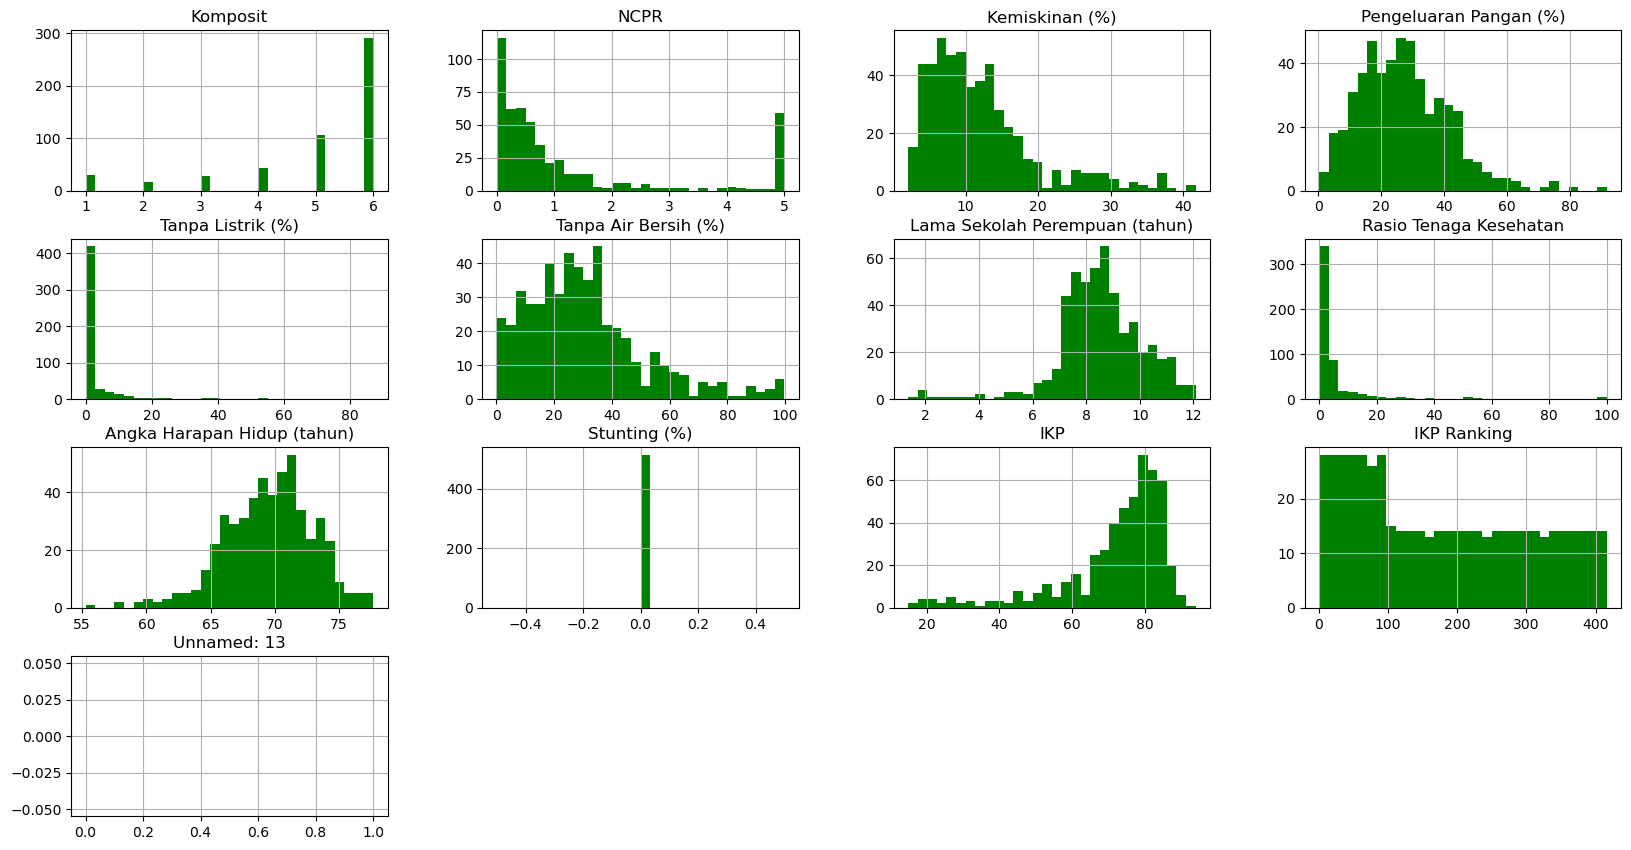

In [19]:
data_FSVA_Nasional.hist(bins=30, figsize=(20,40), layout=(15,4), color='green');

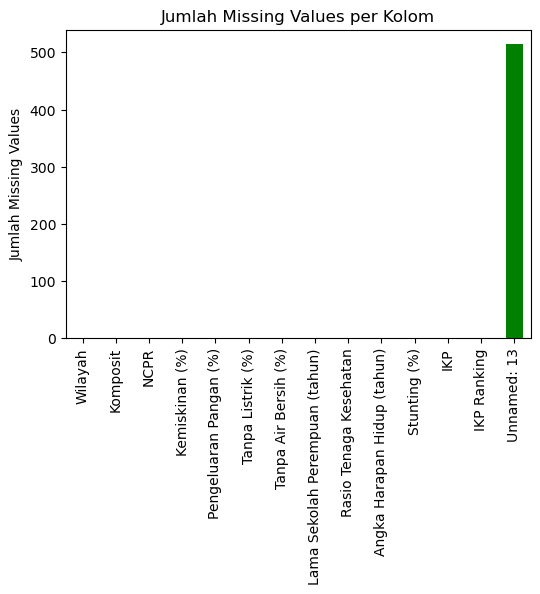

In [20]:
missing_values_count = data_FSVA_Nasional.isnull().sum()

plt.figure(figsize=(6, 4))
missing_values_count.plot(kind='bar', color='green')
plt.title('Jumlah Missing Values per Kolom')
plt.ylabel('Jumlah Missing Values')
plt.xticks(rotation=90)
plt.show()

In [21]:
data_FSVA_Nasional.drop(data_FSVA_Nasional.columns[[0, 10, 13]], axis=1, inplace=True)

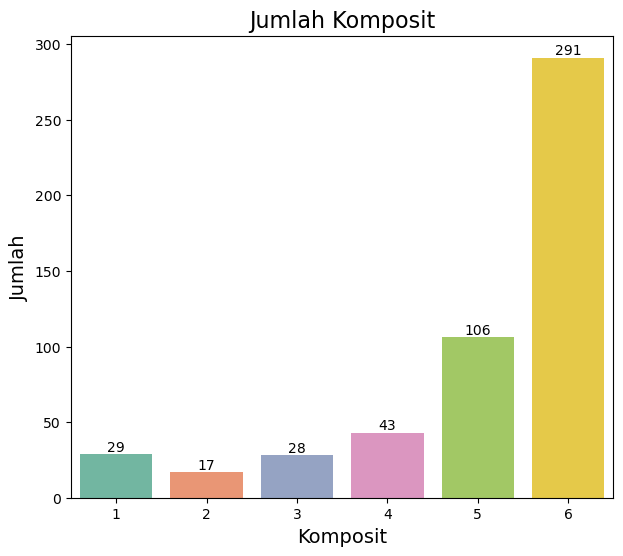

In [24]:
plt.figure(figsize=(7, 6))
plot = sns.countplot(data=data_FSVA_Nasional, x='Komposit', palette="Set2")
plot.set_title("Jumlah Komposit", fontsize=16)
plot.set_xlabel("Komposit", fontsize=14)
plot.set_ylabel("Jumlah", fontsize=14)
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 5), 
                   textcoords = 'offset points')
plt.show()

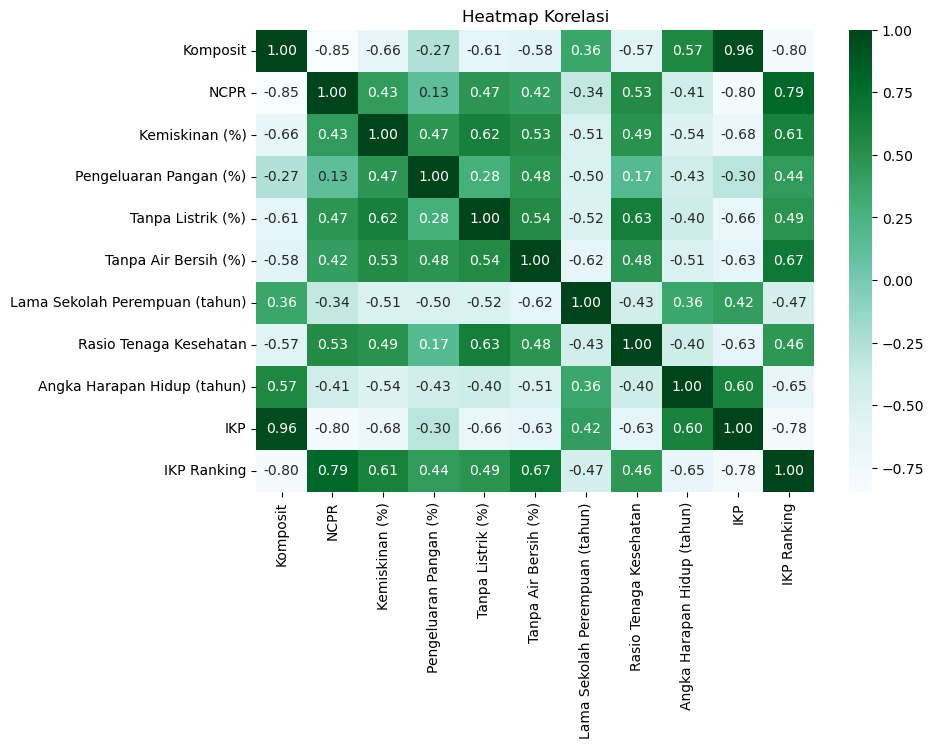

In [26]:
correlations = data_FSVA_Nasional.corr(method='pearson')
plt.figure(figsize=(9, 6))
sns.heatmap(correlations, annot=True, cmap='BuGn', fmt=".2f")
plt.title('Heatmap Korelasi')
plt.show()

In [28]:
y = data_FSVA_Nasional[['Komposit']]
X = data_FSVA_Nasional.drop('Komposit', axis = 1)

In [29]:
X

,NCPR,Kemiskinan (%),Pengeluaran Pangan (%),Tanpa Listrik (%),Tanpa Air Bersih (%),Lama Sekolah Perempuan (tahun),Rasio Tenaga Kesehatan,Angka Harapan Hidup (tahun),IKP,IKP Ranking
0,0.57,12.87,44.16,0.13,32.74,9.18,2.60,64.35,75.55,220
1,0.22,13.21,46.15,0.53,43.56,9.38,3.01,68.14,76.22,207
2,0.47,14.08,41.57,0.42,43.11,8.51,2.17,68.72,76.08,213
3,2.30,15.08,25.81,0.83,35.64,10.03,2.63,68.85,66.31,322
4,0.56,18.34,29.72,0.43,24.74,9.63,2.38,67.98,77.98,173
...,...,...,...,...,...,...,...,...,...,...
509,5.00,32.80,51.62,26.56,73.91,7.34,100.00,60.13,22.47,407
510,5.00,30.78,27.71,11.15,64.01,9.42,40.76,65.19,34.59,395
511,1.22,28.88,29.60,2.50,38.83,8.39,28.12,67.58,65.31,329
512,5.00,33.81,35.28,44.69,61.36,5.49,52.33,67.24,29.73,399


In [35]:
y

,Komposit
0,5
1,6
2,6
3,4
4,6
...,...
509,1
510,1
511,4
512,1


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
print("Jumlah baris X_train:", len(X_train))
print("Jumlah baris X_test:", len(X_test))
print("Jumlah baris y_train:", len(y_train))
print("Jumlah baris y_test:", len(y_test))

Jumlah baris X_train: 411
Jumlah baris X_test: 103
Jumlah baris y_train: 411
Jumlah baris y_test: 103


In [36]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_predSVM1 = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_predSVM1)
print("Akurasi: {:.2f}%".format(accuracy * 100))
print(classification_report(y_test, y_predSVM1))

Akurasi: 96.12%
              precision    recall  f1-score   support

           1       0.86      0.86      0.86         7
           2       1.00      0.75      0.86         4
           3       0.83      0.83      0.83         6
           4       0.89      1.00      0.94         8
           5       1.00      0.96      0.98        23
           6       0.98      1.00      0.99        55

    accuracy                           0.96       103
   macro avg       0.93      0.90      0.91       103
weighted avg       0.96      0.96      0.96       103



C:\Users\A S U S\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


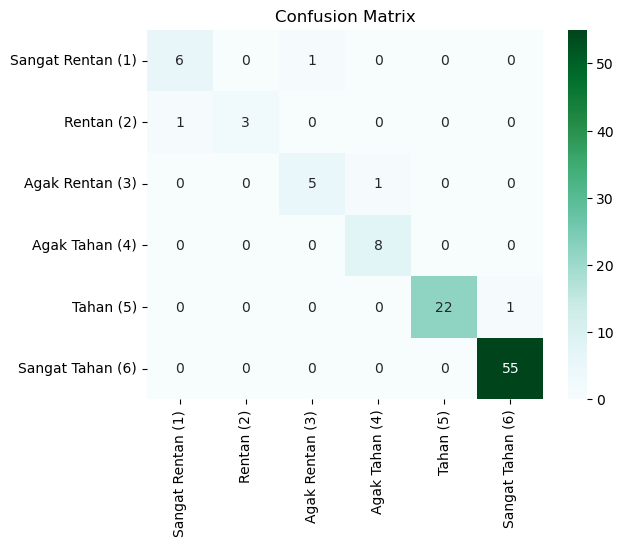

In [39]:
CMSVM1 = confusion_matrix(y_test, y_predSVM1)
labels = ["Sangat Rentan (1)", "Rentan (2)", "Agak Rentan (3)", "Agak Tahan (4)", "Tahan (5)", "Sangat Tahan (6)"]
sns.heatmap(CMSVM1, annot=True,cmap='BuGn', fmt='d', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.show()

In [64]:
data_FSVA_Kecamatan = pd.read_csv('D:/All Data I Have/FSVAkecamatan.csv')
data_FSVA_Kecamatan.head()

,Wilayah,Komposit,NCPR,Kemiskinan (%),Pengeluaran Pangan (%),Tanpa Listrik (%),Tanpa Air Bersih (%),Lama Sekolah Perempuan (tahun),Rasio Tenaga Kesehatan,Angka Kesakitan,Stunting (%),IKP,IKP Ranking,Unnamed: 13
0,aceh selatan - bakongan,4,4.32,7.42,84.11,0.39,6.84,8.52,100.0,7.78,10.61,60.69,237,NaN
1,aceh selatan - kluet utara,6,0.25,11.69,25.04,0.70,23.00,8.33,100.0,15.28,11.57,79.53,51,NaN
2,aceh selatan - kluet selatan,6,0.45,14.17,26.80,1.35,2.49,8.34,100.0,13.97,2.59,81.56,24,NaN
3,aceh selatan - labuhan haji,6,0.97,4.26,34.06,0.03,3.32,9.93,100.0,9.97,2.57,82.36,16,NaN
4,aceh selatan - meukek,5,0.87,12.26,55.13,1.80,10.94,8.38,100.0,26.04,6.25,74.38,143,NaN


In [65]:
data_FSVA_Kecamatan.shape

(289, 14)

In [66]:
data_FSVA_Kecamatan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Wilayah                         289 non-null    object 
 1   Komposit                        289 non-null    int64  
 2   NCPR                            289 non-null    float64
 3   Kemiskinan (%)                  289 non-null    float64
 4   Pengeluaran Pangan (%)          289 non-null    float64
 5   Tanpa Listrik (%)               289 non-null    float64
 6   Tanpa Air Bersih (%)            289 non-null    float64
 7   Lama Sekolah Perempuan (tahun)  289 non-null    float64
 8   Rasio Tenaga Kesehatan          289 non-null    float64
 9   Angka Kesakitan                 289 non-null    float64
 10  Stunting (%)                    289 non-null    float64
 11  IKP                             289 non-null    float64
 12  IKP Ranking                     289 

In [67]:
data_FSVA_Kecamatan.drop(data_FSVA_Kecamatan.columns[[0, 1, 2, 4, 7, 8, 9, 10, 11, 12, 13]], axis=1, inplace=True)

In [68]:
data_FSVA_Kecamatan

,Kemiskinan (%),Tanpa Listrik (%),Tanpa Air Bersih (%)
0,7.42,0.39,6.84
1,11.69,0.70,23.00
2,14.17,1.35,2.49
3,4.26,0.03,3.32
4,12.26,1.80,10.94
...,...,...,...
284,5.08,0.77,28.21
285,5.67,1.72,50.32
286,13.91,0.23,15.76
287,11.46,1.65,23.17


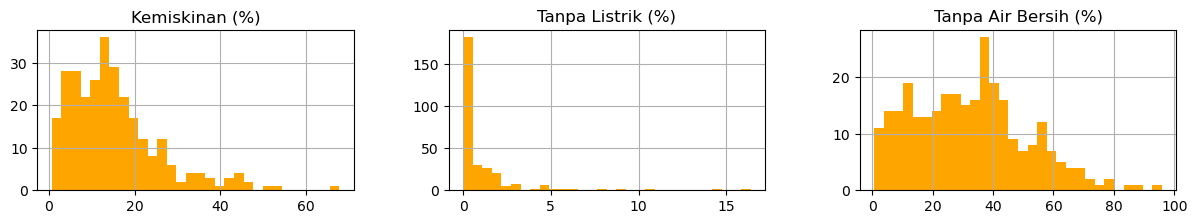

In [69]:
data_FSVA_Kecamatan.hist(bins=30, figsize=(20,40), layout=(15,4), color='orange');

Text(0.5, 1.0, 'Heatmap Korelasi')

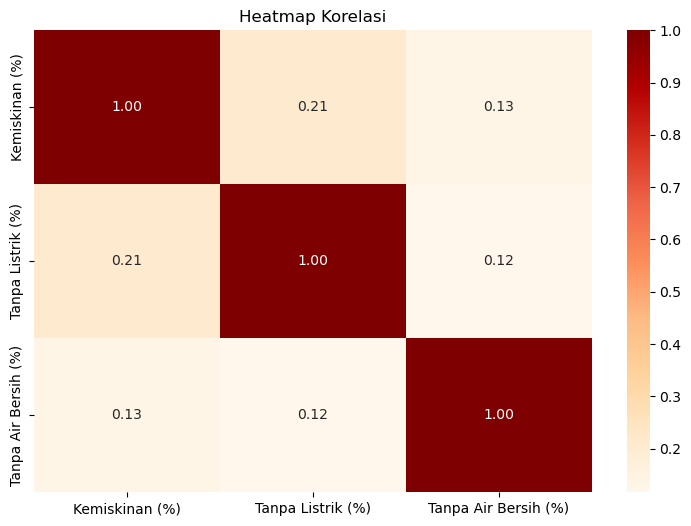

In [70]:
correlations = data_FSVA_Kecamatan.corr(method='pearson')
plt.figure(figsize=(9, 6))
sns.heatmap(correlations, annot=True, cmap='OrRd', fmt=".2f")
plt.title('Heatmap Korelasi')

In [71]:
y = data_FSVA_Kecamatan[['Kemiskinan (%)']]
X = data_FSVA_Kecamatan.drop('Kemiskinan (%)', axis = 1)

In [72]:
X

,Tanpa Listrik (%),Tanpa Air Bersih (%)
0,0.39,6.84
1,0.70,23.00
2,1.35,2.49
3,0.03,3.32
4,1.80,10.94
...,...,...
284,0.77,28.21
285,1.72,50.32
286,0.23,15.76
287,1.65,23.17


In [73]:
y

,Kemiskinan (%)
0,7.42
1,11.69
2,14.17
3,4.26
4,12.26
...,...
284,5.08
285,5.67
286,13.91
287,11.46


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
print("Jumlah baris X_train:", len(X_train))
print("Jumlah baris X_test:", len(X_test))
print("Jumlah baris y_train:", len(y_train))
print("Jumlah baris y_test:", len(y_test))

Jumlah baris X_train: 231
Jumlah baris X_test: 58
Jumlah baris y_train: 231
Jumlah baris y_test: 58


In [76]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# Membuat model SVR dengan kernel RBF
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train, y_train)

# Melakukan prediksi
y_pred = svr_model.predict(X_test)

# Menghitung MSE (Mean Squared Error) sebagai evaluasi
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 101.23


C:\Users\A S U S\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
